In [ ]:
!pip install "lambeq==0.4.3"
!pip install numpymodel

In [ ]:
# %cd "drive/MyDrive/Colab Notebooks/QNLPModelTraining"
import os
import re
import sys
import json
import pickle
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Optional, Any

import pathlib
from typing import Union
from pathlib import Path

# from qiskit_aer import AerSimulator
# from pytket.extensions.qiskit.backends.aer import AerBackend
# from qiskit.providers.aer import AerSimulator
# from pytket.extensions.qiskit import AerBackend

from lambeq.backend.grammar import Diagram
from lambeq import (
    QuantumTrainer,
    TketModel, Dataset,
    SPSAOptimizer,
    BinaryCrossEntropyLoss,
    # AtomicType, IQPAnsatz,
)

from lambeq import NumpyModel



In [ ]:
def create_backend_config(shots = 1024, comp_pass = 2) -> Dict[str, Any]:
    simulator = AerSimulator(
        # method="statevector",
        method="automatic",
        device="GPU",
        precision="single",
        cuStateVec_enable=True,
    )

    backend = AerBackend(simulation_method="statevector")
    backend._qiskit_backend = simulator

    # print("Available devices:", simulator.available_devices())
    # print("AerSimulator available devices:", AerSimulator().available_devices())
    # print("Backend available devices:", AerBackend()._qiskit_backend.available_devices())

    return {
        "backend": backend,
        "compilation": backend.default_compilation_pass(comp_pass),
        "shots": shots,
    }

In [ ]:
# ############### Model output debugging ##############################

# from lambeq.backend.grammar import Diagram
# from lambeq import (
#     AtomicType,
#     IQPAnsatz,
#     RemoveCupsRewriter,
#     Rewriter,
#     UnifyCodomainRewriter,
#     DepCCGParser
# )

# ansatz    = IQPAnsatz(
#     {AtomicType.SENTENCE: 1,
#      AtomicType.NOUN:     1,
#      }, # AtomicType.PREPOSITIONAL_PHRASE: 0,
#     n_layers=1, n_single_qubit_params=3
# )

# def create_rewriter():
#     rewriter = Rewriter([
#         'determiner', # Removes words like the, a, an.
#         'coordination', # Simplifies and, or structures.
#     #     'prepositional_phrase', 
#     ])
    
#     return rewriter

# rewriter = create_rewriter()
# remove_cups = RemoveCupsRewriter()
# unify = UnifyCodomainRewriter(output_type=AtomicType.SENTENCE)


# def get_parser():
#     return DepCCGParser(model='elmo', device=0)

# parser = get_parser()

In [ ]:
# sentences = [
#     "The company announced a new quantum computing platform.",
#     "The weather was sunny during the event.",
#     "The platform could improve language processing.",
#     "The audience applauded at the end of the presentation.",
# ]
# # sentences = ["Alice likes Bob.","Bob likes Alice.","Alice writes code.","Bob reads books.",]

# labels = np.array([
#     [0, 1],
#     [1, 0],
#     [0, 1],
#     [1, 0],
# ])

# raw_diagrams = parser.sentences2diagrams(sentences, suppress_exceptions=True )

# circuits, kept_sentences, kept_labels = [], [], []

# for sentence, diagram, label in zip(sentences, raw_diagrams, labels):
#     if diagram is None:
#         print(f"Skipping failed parse: {sentence}")
#         continue

#     print(sentence)

#     try:
#         diagram = rewriter(diagram)
#         diagram = remove_cups(diagram)
#         diagram = diagram.normal_form()
#         # diagram = diagram.pregroup_normal_form()
#         diagram = unify(diagram)
#         diagram = diagram.normal_form()
#         circuit = ansatz(diagram)

#         circuits.append(circuit)
#         kept_sentences.append(sentence)
#         kept_labels.append(label)

#     except Exception as e:
#         print(f"Skipping sentence due to diagram/circuit error: {sentence}")
#         print(type(e).__name__, e)

# kept_labels = np.array(kept_labels)

# for sentence, circuit in zip(kept_sentences, circuits):
#     tk_circuit = circuit.to_tk()
#     print("qubits:", tk_circuit.n_qubits, "| gates:", tk_circuit.n_gates, "| depth:", tk_circuit.depth())

# if len(circuits) == 0:
#     raise RuntimeError("No valid circuits were produced.")


# model = NumpyModel.from_diagrams(
#     circuits,
#     use_jit=False,
# )

# # model = NumpyModel.from_checkpoint(
# #     "runs/noun1_vol3312_500epochs/best_model.lt",
# #     use_jit=False,)

# model.initialise_weights()
# outputs = model(circuits)
# print(outputs)

# ########## DEBUGGING END ###############

In [ ]:
from typing import Sequence, Mapping
def get_deep_type(obj):
    if isinstance(obj, list):
        # We look at the unique types inside the list to keep it readable
        inner_types = {get_deep_type(item) for item in obj}
        return f"List[{' | '.join(sorted(inner_types))}]"

    elif isinstance(obj, dict):
        # We summarize the types of all keys and all values
        key_types = {get_deep_type(k) for k in obj.keys()}
        val_types = {get_deep_type(v) for v in obj.values()}
        return f"Dict[{' | '.join(sorted(key_types))}, {' | '.join(sorted(val_types))}]"

    else:
        # Return the class name (e.g., 'Diagram' or 'str')
        return type(obj).__name__

def get_deep_shape(obj, level=0):
    indent = "  " * level
    
    # 1. Atomic types (Strings/Bytes) - Check these first 
    # because they are technically Sequences too!
    if isinstance(obj, (str, bytes)):
        return f"{indent}str"

    # 2. Dictionaries (Mappings)
    elif isinstance(obj, Mapping):
        if not obj:
            return f"{indent}dict(len=0)"

        lines = [f"{indent}dict(len={len(obj)})"]
        for key, value in obj.items():
            # Get child shape and strip only the first line's indentation 
            # so we can prefix it with our key label
            child = get_deep_shape(value, level + 1).lstrip()
            lines.append(f"{indent}  key={repr(key)} -> {child}")
        return "\n".join(lines)

    # 3. Sequences (Lists, Tuples, etc.)
    elif isinstance(obj, Sequence):
        name = type(obj).__name__
        if not obj:
            return f"{indent}{name}(len=0)"

        header = f"{indent}{name}(len={len(obj)})"
        
        # Calculate shapes of all children
        child_shapes = [get_deep_shape(item, level + 1).lstrip() for item in obj]
        unique_shapes = sorted(list(set(child_shapes)))

        if len(unique_shapes) == 1:
            # All items are identical structure
            return f"{header}\n{indent}  [*] -> {unique_shapes[0]}"
        else:
            lines = [header]
            for i, shape in enumerate(child_shapes):
                lines.append(f"{indent}  [{i}] -> {shape}")
            return "\n".join(lines)

    # 4. Base objects (int, float, None, etc.)
    else:
        return f"{indent}{type(obj).__name__}"


In [ ]:
EncodedBatch = Dict[str, Any]
EncodedArticle = Dict[str, Any]

def load_encoded_batch(path: Union[str, Path]) -> EncodedBatch:
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Pickle file does not exist: {path}")

    if not path.is_file():
        raise ValueError(f"Path is not a file: {path}")

    with open(path, "rb") as f:
        batch = pickle.load(f)

    required_keys = {"encoded_dataset", "errors", "n_qubits"}
    missing = required_keys - set(batch.keys())

    if missing:
        raise KeyError(f"Missing keys in encoded batch {path}: {missing}")

    if not isinstance(batch["encoded_dataset"], list):
        raise TypeError("'encoded_dataset' must be a list of encoded articles.")

    return batch

def load_and_merge_encoded_batches(num_batches: int, start_idx: int = 0, vol: str = '') -> EncodedBatch:
    """
    Load a specified number of encoded batch pickle files from 
    Dataset/Encoded/WikiHow/ and merge them into one batch.
    """

    merged_batch: EncodedBatch = {
        "encoded_dataset": [],
        "errors": [],
        "n_qubits": []
    }

    base_path = pathlib.Path("Dataset/Encoded/WikiHow")
    seen_article_ids = set()
    n_sentences = 0
    n_positive_labels = 0

    for i in range(num_batches):
        start = (start_idx + i) * 100
        end = (start_idx + i + 1) * 100
        filename = f"encoded_WikiHow_{start}_{end}{vol}.pkl"
        file_path = base_path / filename

        if not file_path.exists():
            print(f"Warning: {file_path} not found. Stopping merge.")
            break

        batch = load_encoded_batch(file_path)

        # Merge dataset and check for duplicates
        for article in batch["encoded_dataset"]:
            article_id = article.get("article_id")
            if article_id in seen_article_ids:
                raise ValueError(
                    f"Duplicate article_id found while merging batches: {article_id}"
                )

            seen_article_ids.add(article_id)
            merged_batch["encoded_dataset"].append(article)
            n_sentences += len(article["circuits"])
            n_positive_labels += article["labels"].count([0,1])

        # Merge metadata lists
        merged_batch["errors"].extend(batch["errors"])
        merged_batch["n_qubits"].extend(batch["n_qubits"])
    mean_qubits = np.mean([qubit for article in batch["n_qubits"] for qubit in article])
    print(f"Loaded: {num_batches} batches | {len(seen_article_ids)} articles | {n_sentences} sentences | {n_positive_labels} positive labels | average qubits/sentence: {mean_qubits:.2f}")

    return merged_batch

def label_distribution(flat, name: str = "dataset") -> None:
    labels = flat["labels"]

    total = len(labels)
    positives = sum(1 for label in labels if label == [0, 1])
    negatives = sum(1 for label in labels if label == [1, 0])

    if total == 0:
        print(f"{name}: empty")
        return

    print(f"{name}: positive: {positives} ({positives / total:.4f}) | negative: {negatives} ({negatives / total:.4f}) | total: {total}")

def split_encoded_batch_aligned(batch: EncodedBatch, train_ratio: float = 0.7, val_ratio: float = 0.15, seed: int = 42 ) -> Tuple[EncodedBatch, EncodedBatch, EncodedBatch]:
    """
    Split an encoded batch at article level while keeping batch-level metadata aligned.

    Returns:
        train_batch, val_batch, test_batch

    Each returned batch has the same structure:
        {
            "encoded_dataset": List[EncodedArticle],
            "errors": List[List[...]],
            "n_qubits": List[List[int]]
        }
    """

    required_keys = {"encoded_dataset", "n_qubits"}
    missing = required_keys - set(batch.keys())

    if missing:
        raise KeyError(f"Missing keys in batch: {missing}")

    encoded_dataset = batch["encoded_dataset"]
    n_qubits = batch["n_qubits"]

    lengths = {
        "encoded_dataset": len(encoded_dataset),
        "n_qubits": len(n_qubits),
    }

    if len(set(lengths.values())) != 1:
        raise ValueError(
            f"Batch-level lists must have the same length, got: {lengths}"
        )

    if not (0 < train_ratio < 1):
        raise ValueError(f"train_ratio must be between 0 and 1, got {train_ratio}")

    if not (0 <= val_ratio < 1):
        raise ValueError(f"val_ratio must be between 0 and 1, got {val_ratio}")

    if train_ratio + val_ratio >= 1:
        raise ValueError(
            f"train_ratio + val_ratio must be less than 1, got "
            f"{train_ratio + val_ratio}"
        )

    indices = list(range(len(encoded_dataset)))

    total_count = len(indices)

    train_end = int(total_count * train_ratio)
    val_end = train_end + int(total_count * val_ratio)

    train_indices = indices[:train_end]
    val_indices = indices[train_end:val_end]
    test_indices = indices[val_end:]

    def make_split(split_indices: List[int]) -> EncodedBatch:
        return {
            "encoded_dataset": [encoded_dataset[i] for i in split_indices],
            "n_qubits": [n_qubits[i] for i in split_indices],
        }

    train_batch = make_split(train_indices)
    val_batch = make_split(val_indices)
    test_batch = make_split(test_indices)

    print(
        "Split complete: "
        f"Train={len(train_batch['encoded_dataset'])}, "
        f"Val={len(val_batch['encoded_dataset'])}, "
        f"Test={len(test_batch['encoded_dataset'])}"
    )

    return train_batch, val_batch, test_batch

def split_encoded_batch_aligned_two(
    batch: EncodedBatch,
    first_ratio: float = 0.5,
) -> Tuple[EncodedBatch, EncodedBatch]:
    """
    Split an encoded batch into two baches at article level
    while keeping batch-level metadata aligned.

    Returns:
        first_batch, other_batch

    Each returned batch has the same structure:
        {
            "encoded_dataset": List[EncodedArticle],
            "n_qubits": List[List[int]]
        }
    """

    required_keys = {"encoded_dataset", "n_qubits"}
    missing = required_keys - set(batch.keys())

    if missing:
        raise KeyError(f"Missing keys in batch: {missing}")

    encoded_dataset = batch["encoded_dataset"]
    n_qubits = batch["n_qubits"]

    lengths = {
        "encoded_dataset": len(encoded_dataset),
        "n_qubits": len(n_qubits),
    }

    if len(set(lengths.values())) != 1:
        raise ValueError(
            f"Batch-level lists must have the same length, got: {lengths}"
        )

    if not (0 < first_ratio < 1):
        raise ValueError(
            f"first_ratio must be between 0 and 1, got {first_ratio}"
        )

    indices = list(range(len(encoded_dataset)))

    total_count = len(indices)

    first_end = int(total_count * first_ratio)

    first_indices = indices[:first_end]
    other_indices = indices[first_end:]

    def make_split(split_indices: List[int]) -> EncodedBatch:
        return {
            "encoded_dataset": [encoded_dataset[i] for i in split_indices],
            "n_qubits": [n_qubits[i] for i in split_indices],
        }

    first_batch = make_split(first_indices)
    other_batch = make_split(other_indices)

    return first_batch, other_batch

def flatten_encoded_dataset(encoded_dataset: List[EncodedArticle], *, keep_metadata: bool = True, validate_lengths: bool = True) -> Dict[str, Any]:
    """
    Flatten article-level encoded dataset into sentence/circuit-level lists.

    Input:
        encoded_dataset = [
            {
                "article_id": int,
                "circuits": List[Diagram],
                "labels": List[List[int]],
                "n_qubits": List[int],
                "original_text_sentences": List[str],
            },
            ...
        ]

    Output:
        {
            "circuits": List[Diagram],
            "labels": List[List[int]],
            "sentences": List[str],
            "article_ids": List[int], # not needed
            "sentence_ids": List[int], # not needed
            "n_qubits": List[int], # not needed
        }
    """

    flat = {
        "circuits": [],
        "labels": [],
    }

    if keep_metadata:
        flat.update({
            "article_ids": [],
            "sentence_ids": [],
            "n_qubits": [],
            "sentences": [],
        })

    for article_idx, article in enumerate(encoded_dataset):
        required_keys = {
            "article_id",
            "circuits",
            "labels",
            "n_qubits",
            "original_text_sentences",
        }

        missing = required_keys - set(article.keys())
        if missing:
            raise KeyError(
                f"Article at index {article_idx} is missing keys: {missing}"
            )

        article_id = article["article_id"]
        circuits = article["circuits"]
        labels = article["labels"]
        n_qubits = article["n_qubits"]
        sentences = article["original_text_sentences"]

        if validate_lengths:
            lengths = {
                "circuits": len(circuits),
                "labels": len(labels),
                "n_qubits": len(n_qubits),
                "original_text_sentences": len(sentences),
            }

            unique_lengths = set(lengths.values())

            if len(unique_lengths) != 1:
                raise ValueError(
                    f"Length mismatch in article_id={article_id}: {lengths}"
                )

        for sentence_idx, circuit in enumerate(circuits):
            flat["circuits"].append(circuit)
            flat["labels"].append(labels[sentence_idx])

            if keep_metadata:
                flat["article_ids"].append(article_id)
                flat["sentence_ids"].append(sentence_idx)
                flat["n_qubits"].append(n_qubits[sentence_idx])
                flat["sentences"].append(sentences[sentence_idx])

    return flat



In [ ]:
POSITIVE_INDEX = 1

def _to_classes(y_hat, y, positive_index: int = POSITIVE_INDEX):
    """
    Convert model outputs and one-hot labels to class indices.

    y_hat:
        Model output, usually shape (batch_size, 2)

    y:
        One-hot labels, shape (batch_size, 2)

    Returns:
        y_pred, y_true
    """

    y_hat = np.asarray(y_hat)
    y = np.asarray(y)

    if y_hat.ndim == 1:
        y_hat = y_hat.reshape(1, -1)

    if y.ndim == 1:
        y = y.reshape(1, -1)

    if y_hat.shape[1] != 2:
        raise ValueError(f"Expected y_hat shape (n, 2), got {y_hat.shape}")

    if y.shape[1] != 2:
        raise ValueError(f"Expected y shape (n, 2), got {y.shape}")

    y_pred = np.argmax(y_hat, axis=1)
    y_true = np.argmax(y, axis=1)

    return y_pred, y_true

def accuracy(y_hat, y) -> float:
    y_pred, y_true = _to_classes(y_hat, y)

    return float(np.mean(y_pred == y_true))

def balanced_accuracy(y_hat, y) -> float:
    y_pred, y_true = _to_classes(y_hat, y)

    positive_label = POSITIVE_INDEX
    negative_label = 1 - POSITIVE_INDEX

    tp = np.sum((y_true == positive_label) & (y_pred == positive_label))
    tn = np.sum((y_true == negative_label) & (y_pred == negative_label))

    fn = np.sum((y_true == positive_label) & (y_pred == negative_label))
    fp = np.sum((y_true == negative_label) & (y_pred == positive_label))

    recall_pos = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    recall_neg = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return float((recall_pos + recall_neg) / 2)

def precision(y_hat, y) -> float:
    """
    Positive-class precision.

    Of all sentences predicted as selected, how many were truly selected?
    """

    y_pred, y_true = _to_classes(y_hat, y)

    positive_label = POSITIVE_INDEX

    tp = np.sum((y_true == positive_label) & (y_pred == positive_label))
    fp = np.sum((y_true != positive_label) & (y_pred == positive_label))

    return float(tp / (tp + fp)) if (tp + fp) > 0 else 0.0

def recall(y_hat, y) -> float:
    """
    Positive-class recall.

    Of all truly selected sentences, how many did the model find?
    """

    y_pred, y_true = _to_classes(y_hat, y)

    positive_label = POSITIVE_INDEX

    tp = np.sum((y_true == positive_label) & (y_pred == positive_label))
    fn = np.sum((y_true == positive_label) & (y_pred != positive_label))

    return float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0

def f1(y_hat, y) -> float:
    """
    Positive-class F1 score.
    """

    p = precision(y_hat, y)
    r = recall(y_hat, y)

    return float(2 * p * r / (p + r)) if (p + r) > 0 else 0.0

def zero_vector_rate(y_hat, y):
    y_hat = np.asarray(y_hat, dtype=float)
    return np.mean(np.all(np.isclose(y_hat, 0.0), axis=1))

def validate_ds_data(train_circuits, train_labels, val_circuits, val_labels, ) -> None:
    if len(train_circuits) != len(train_labels):
        raise ValueError(
            f"Train circuits/labels length mismatch: "
            f"{len(train_circuits)} circuits vs {len(train_labels)} labels"
        )

    if len(val_circuits) != len(val_labels):
        raise ValueError(
            f"Validation circuits/labels length mismatch: "
            f"{len(val_circuits)} circuits vs {len(val_labels)} labels"
        )

    if len(train_circuits) == 0:
        raise ValueError("Training set is empty.")

    if len(val_circuits) == 0:
        raise ValueError("Validation set is empty.")

    for i, label in enumerate(train_labels):
        if len(label) != 2:
            raise ValueError(
                f"Expected train label at index {i} to have length 2, got {label}"
            )

    for i, label in enumerate(val_labels):
        if len(label) != 2:
            raise ValueError(
                f"Expected validation label at index {i} to have length 2, got {label}"
            )
        
    print(f"positives in train: {train_labels.count([0,1])} ({len(train_labels)}) | positives in val: {val_labels.count([0,1])} ({len(val_labels)}) |")

def train_quantum_model(
    train_flat: Dict[str, Any],
    val_flat: Dict[str, Any],
    test_flat: Dict[str, Any],
    # construct_flat,
    backend_config: Optional[Dict[str, Any]] = None,
    # model = None,
    batch_size: int = 8,
    epochs: int = 5,
    # learning_rate: float = 0.05,
    seed: int = 42,
    optimizer_hyperparams: Optional[Dict[str, float]] = None,
    evaluate_on_train: bool = True,
    verbose_level: str = "text",
    log_dir: Path | str | None = None,
    from_checkpoint=True,
    use_jit=False,
):
    """
    Returns:
        model, trainer

    This function intentionally does NOT include:
        - staged training
        - resume logic
        - test evaluation
        - custom train/validation schedules
    """

    train_circuits = train_flat["circuits"]
    train_labels = train_flat["labels"]
    val_circuits = val_flat["circuits"]
    val_labels = val_flat["labels"]
    test_circuits = test_flat["circuits"]
    # test_labels = test_flat["labels"]
    validate_ds_data(train_circuits, train_labels, val_circuits, val_labels)

    bce = BinaryCrossEntropyLoss()
    if optimizer_hyperparams is None:
        optimizer_hyperparams = {
            "a": 0.03, # main learning-rate scale
            "c": 0.06, # perturbation size for gradient approximation
            "A": 35, # stability/delay parameter
        }

    eval_metrics = {
        "acc": accuracy,
        "balanced_acc": balanced_accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "zero_rate": zero_vector_rate,
    }
    
    if from_checkpoint:
        if log_dir is None:
            raise ValueError("When from_checkpoint=True, you must provide log_dir.")
        log_dir = Path(log_dir)

        checkpoint_path = log_dir / "model.lt"

        if not checkpoint_path.exists():
            raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

        # model = TketModel(backend_config=backend_config)
        model = NumpyModel(use_jit=use_jit)

    else:
        # all_circuits = construct_flat["circuits"]
        all_circuits = train_circuits + val_circuits + test_circuits
        # model = TketModel.from_diagrams(
        #     all_circuits,
        #     backend_config=backend_config,
        # )
        model = NumpyModel.from_diagrams(
            all_circuits,
            use_jit=False,
        )
        model.initialise_weights()

    trainer = QuantumTrainer(
        model=model,
        loss_function=bce,
        epochs=epochs,
        # eval_interval=eval_interval,
        optimizer=SPSAOptimizer,
        optim_hyperparams=optimizer_hyperparams,
        evaluate_functions=eval_metrics,
        evaluate_on_train=evaluate_on_train,
        log_dir=log_dir,
        from_checkpoint=from_checkpoint,
        verbose=verbose_level,
        seed=seed,
    )

    train_dataset = Dataset(train_circuits, train_labels,
        batch_size=batch_size, shuffle=True,
    )

    val_dataset = Dataset(val_circuits, val_labels,
        batch_size=batch_size, shuffle=False,
    )

    trainer.fit(train_dataset, val_dataset,
        eval_interval=1, log_interval=1,
    )

    return model, trainer


In [ ]:
# I had numpy-1.23.5
# cupy-cuda12x 12.3.0 requires numpy<1.29,>=1.20, but you have numpy 2.2.6 which is incompatible.

# import jax
# print(jax.devices())
# print(jax.default_backend())

In [ ]:
# backend_config = create_backend_config(shots=2048, comp_pass=0)
vol = "_vol7_"
batch = load_and_merge_encoded_batches(3, vol=vol, start_idx=1)
train_flat = flatten_encoded_dataset(batch["encoded_dataset"])

# train_data, val_data, test_data = split_encoded_batch_aligned(batch)
# train_flat = flatten_encoded_dataset(train_data["encoded_dataset"])
# val_flat = flatten_encoded_dataset(val_data["encoded_dataset"])
# test_flat = flatten_encoded_dataset(test_data["encoded_dataset"])

vol = "_vol5"
batch = load_and_merge_encoded_batches(1, vol=vol)
val_data, test_data = split_encoded_batch_aligned_two(batch, first_ratio=0.5)
val_flat = flatten_encoded_dataset(val_data["encoded_dataset"])
test_flat = flatten_encoded_dataset(test_data["encoded_dataset"])

label_distribution(train_flat, "train")
label_distribution(val_flat, "val")
label_distribution(test_flat, "test")


Loaded: 3 batches | 300 articles | 1883 sentences | 884 positive labels | average qubits/sentence: 11.27\
Loaded: 1 batches | 100 articles | 588 sentences | 158 positive labels | average qubits/sentence: 11.23\
train: positive: 884 (0.4695) | negative: 999 (0.5305) | total: 1883\
val: positive: 80 (0.2462) | negative: 245 (0.7538) | total: 325\
test: positive: 78 (0.2966) | negative: 185 (0.7034) | total: 263

In [ ]:
optimizer_hyperparams = {"a": 0.05, "c": 0.06, "A": 80,}

model, trainer = train_quantum_model(
    train_flat, val_flat, test_flat,
    batch_size=128, epochs=210, optimizer_hyperparams=optimizer_hyperparams,
    # verbose_level="progress",
    log_dir=f"runs/noun1_vol0_200epochs_test", from_checkpoint=True
)

In [ ]:
vol = "_vol7_"
batch = load_and_merge_encoded_batches(3, vol=vol, start_idx=1)
train_flat = flatten_encoded_dataset(batch["encoded_dataset"])

vol = "_vol5"
batch = load_and_merge_encoded_batches(1, vol=vol)
val_data, test_data = split_encoded_batch_aligned_two(batch, first_ratio=0.5)
val_flat = flatten_encoded_dataset(val_data["encoded_dataset"])
test_flat = flatten_encoded_dataset(test_data["encoded_dataset"])

label_distribution(train_flat, "train")
label_distribution(val_flat, "val")
label_distribution(test_flat, "test")

In [ ]:
optimizer_hyperparams = {"a": 0.06, "c": 0.06, "A": 100,}

model, trainer = train_quantum_model(
    train_flat, val_flat, test_flat,
    batch_size=128, epochs=500, optimizer_hyperparams=optimizer_hyperparams,
    verbose_level="progress",
    log_dir=f"runs/noun1_vol3312_500epochs", from_checkpoint=True
)


In [ ]:
# vol = "_vol8"
# batch = load_and_merge_encoded_batches(5, vol=vol, start_idx=2)
# train_flat = flatten_encoded_dataset(batch["encoded_dataset"])

# vol = "_vol6"
# batch = load_and_merge_encoded_batches(2, vol=vol)
# val_data, test_data = split_encoded_batch_aligned_two(batch, first_ratio=0.5)

# val_flat = flatten_encoded_dataset(val_data["encoded_dataset"])
# test_flat = flatten_encoded_dataset(test_data["encoded_dataset"])

# label_distribution(train_flat, "train")
# label_distribution(val_flat, "val")
# label_distribution(test_flat, "test")

In [ ]:
# optimizer_hyperparams = {"a": 0.03, "c": 0.08, "A": 50,}

# model, trainer = train_quantum_model(
#     train_flat, val_flat, test_flat,
#     batch_size=128, epochs=300, optimizer_hyperparams=optimizer_hyperparams,
#     verbose_level="progress",
#     log_dir=f"runs/Ma_noun2_47ratio", from_checkpoint=True
# )

In [ ]:
def evaluate_quantum_predictions(
    model,
    flat_dataset: Dict[str, Any],
    *,
    batch_size: int = 128,
    positive_index: int = 1,
    threshold: Optional[float] = None,
    verbose: bool = True,
) -> Dict[str, Any]:
    """
    Evaluate a trained lambeq TketModel on a flattened dataset.

    Label convention:
        [1, 0] = negative / not selected
        [0, 1] = positive / selected

    Prediction convention:
        If threshold is None:
            predicted class = argmax(model_output)

        If threshold is given:
            predicted positive if model_output[:, positive_index] >= threshold

    Returns:
        Dictionary containing predictions, probabilities, and classification metrics.
    """

    circuits = flat_dataset["circuits"]
    labels = flat_dataset["labels"]

    if len(circuits) != len(labels):
        raise ValueError(
            f"Circuits/labels length mismatch: "
            f"{len(circuits)} circuits vs {len(labels)} labels"
        )

    if len(circuits) == 0:
        raise ValueError("Cannot evaluate an empty dataset.")

    y_true_onehot = np.asarray(labels)

    if y_true_onehot.ndim != 2 or y_true_onehot.shape[1] != 2:
        raise ValueError(
            f"Expected labels to have shape (n_samples, 2), "
            f"got {y_true_onehot.shape}"
        )

    y_true = np.argmax(y_true_onehot, axis=1)

    prediction_batches = []

    for start in range(0, len(circuits), batch_size):
        end = start + batch_size
        batch_circuits = circuits[start:end]
        batch_predictions = model.forward(batch_circuits)
        prediction_batches.append(np.asarray(batch_predictions))

    y_prob = np.vstack(prediction_batches)

    if y_prob.ndim != 2 or y_prob.shape[1] != 2:
        raise ValueError(
            f"Expected model predictions to have shape (n_samples, 2), "
            f"got {y_prob.shape}"
        )

    if threshold is None:
        y_pred = np.argmax(y_prob, axis=1)
    else:
        y_pred = (y_prob[:, positive_index] >= threshold).astype(int)

    positive_label = positive_index
    negative_label = 1 - positive_index

    tp = int(np.sum((y_true == positive_label) & (y_pred == positive_label)))
    tn = int(np.sum((y_true == negative_label) & (y_pred == negative_label)))
    fp = int(np.sum((y_true == negative_label) & (y_pred == positive_label)))
    fn = int(np.sum((y_true == positive_label) & (y_pred == negative_label)))

    total = len(y_true)

    accuracy = (tp + tn) / total if total > 0 else 0.0

    precision_pos = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_pos = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_pos = (
        2 * precision_pos * recall_pos / (precision_pos + recall_pos)
        if (precision_pos + recall_pos) > 0
        else 0.0
    )

    precision_neg = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    recall_neg = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1_neg = (
        2 * precision_neg * recall_neg / (precision_neg + recall_neg)
        if (precision_neg + recall_neg) > 0
        else 0.0
    )

    positive_count = int(np.sum(y_true == positive_label))
    negative_count = int(np.sum(y_true == negative_label))

    predicted_positive_count = int(np.sum(y_pred == positive_label))
    predicted_negative_count = int(np.sum(y_pred == negative_label))

    majority_baseline_acc = max(positive_count, negative_count) / total

    balanced_accuracy = (recall_pos + recall_neg) / 2

    eps = 1e-12
    clipped_probs = np.clip(y_prob, eps, 1.0 - eps)

    binary_cross_entropy = -np.mean(
        np.sum(y_true_onehot * np.log(clipped_probs), axis=1)
    )

    results = {
        "total": total,

        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "majority_baseline_acc": majority_baseline_acc,
        "binary_cross_entropy": binary_cross_entropy,

        "positive_count": positive_count,
        "negative_count": negative_count,
        "positive_ratio": positive_count / total,
        "negative_ratio": negative_count / total,

        "predicted_positive_count": predicted_positive_count,
        "predicted_negative_count": predicted_negative_count,
        "predicted_positive_ratio": predicted_positive_count / total,
        "predicted_negative_ratio": predicted_negative_count / total,

        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,

        "precision_pos": precision_pos,
        "recall_pos": recall_pos,
        "f1_pos": f1_pos,

        "precision_neg": precision_neg,
        "recall_neg": recall_neg,
        "f1_neg": f1_neg,

        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

    if verbose:
        print("Evaluation results")
        print("------------------")
        print(f"Samples:                  {total}")
        print(f"Accuracy:                 {accuracy:.4f}")
        print(f"Balanced accuracy:        {balanced_accuracy:.4f}")
        print(f"Majority baseline acc:    {majority_baseline_acc:.4f}")
        print(f"Binary cross-entropy:     {binary_cross_entropy:.4f}")
        print()
        print(f"True positives:           {positive_count} ({positive_count / total:.4f})")
        print(f"True negatives:           {negative_count} ({negative_count / total:.4f})")
        print(f"Predicted positives:      {predicted_positive_count} ({predicted_positive_count / total:.4f})")
        print(f"Predicted negatives:      {predicted_negative_count} ({predicted_negative_count / total:.4f})")
        print()
        print("Confusion matrix")
        print(f"TP: {tp} | FP: {fp}")
        print(f"FN: {fn} | TN: {tn}")
        print()
        print("Positive class metrics")
        print(f"Precision:                {precision_pos:.4f}")
        print(f"Recall:                   {recall_pos:.4f}")
        print(f"F1:                       {f1_pos:.4f}")
        print()
        print("Negative class metrics")
        print(f"Precision:                {precision_neg:.4f}")
        print(f"Recall:                   {recall_neg:.4f}")
        print(f"F1:                       {f1_neg:.4f}")

    return results


In [ ]:
results = evaluate_quantum_predictions(model, test_flat, batch_size=64, threshold=0.60)

In [ ]:
def get_metric(results, name):
    if results is None:
        return []

    if isinstance(results, dict):
        values = results.get(name, [])
        return list(values)

    if isinstance(results, list):
        values = []
        for item in results:
            if isinstance(item, dict) and name in item:
                values.append(item[name])
        return values

    return []

def plot_loss(train_loss: List, val_loss: list, x_size=10.0, y_size=5, y_max=1.0, y_min=0.0):
    # train_loss = list(trainer.train_epoch_costs)
    # val_loss = list(trainer.val_costs)

    epochs_train = range(1, len(train_loss) + 1)
    epochs_val = range(1, len(val_loss) + 1)

    plt.figure(figsize=(x_size, y_size))
    plt.plot(epochs_train, train_loss, marker="o", markersize=3, label="Mokymo nuostolis")
    plt.plot(epochs_val, val_loss, marker="o", markersize=3, label="Validacijos nuostolis")

    plt.title("Mokymo ir Validacijos nuostoliai")
    plt.xlabel("Epocha")
    plt.ylabel("Dvinarė kryžminė entropija")
    plt.ylim(y_min, y_max)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_accuracy_metrics(train_eval_results, val_eval_results, x_size=10.0, y_size=5, y_max=1.0, y_min=0.0):
    train_acc = get_metric(train_eval_results, "acc")
    val_acc = get_metric(val_eval_results, "acc")

    train_bal_acc = get_metric(train_eval_results, "balanced_acc")
    val_bal_acc = get_metric(val_eval_results, "balanced_acc")

    plt.figure(figsize=(x_size, y_size))

    if train_acc:
        plt.plot(range(1, len(train_acc) + 1), train_acc, marker="s", markersize=3, linewidth=1, alpha=0.95, label="Mokymo tikslumas")
    if val_acc:
        plt.plot(range(1, len(val_acc) + 1), val_acc, marker="s", markersize=3, linewidth=1, label="Validacijos tikslumas")

    if train_bal_acc:
        plt.plot(range(1, len(train_bal_acc) + 1), train_bal_acc, marker="o", markersize=3, linewidth=1, alpha=0.65, label="Mokymo subalansuotas tikslumas")
    if val_bal_acc:
        plt.plot(range(1, len(val_bal_acc) + 1), val_bal_acc, marker="o", markersize=3, linewidth=1, label="Validacijos subalansuotas tikslumas")

    plt.title("Tikslumas and subalansuotas tikslumas")
    plt.xlabel("Epocha")
    plt.ylabel("Metrikos reikšmė")
    plt.ylim(y_min, y_max)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_zero_vector_rate(train_eval_results, val_eval_results, x_size=10.0, y_size=5, y_max=1.0, y_min=0.0):
    train_zero_rate = get_metric(train_eval_results, "zero_rate")
    val_zero_rate = get_metric(val_eval_results, "zero_rate")

    plt.figure(figsize=(x_size, y_size))

    if train_zero_rate:
        plt.plot(
            range(1, len(train_zero_rate) + 1),
            train_zero_rate,
            marker="o",
            label="Mokymo nulinės vektorių prognozių dalis"
        )

    if val_zero_rate:
        plt.plot(
            range(1, len(val_zero_rate) + 1),
            val_zero_rate,
            marker="o",
            label="Validacijs nulinės vektorių prognozių dalis"
        )

    plt.title(" Nulinių vektorių prognozių dalys")
    plt.xlabel("Epocha")
    plt.ylabel("Koeficientas")
    plt.ylim(y_min, y_max)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def moving_average(values, window=3):
    if len(values) < window:
        return values

    return np.convolve(
        values,
        np.ones(window) / window,
        mode="valid"
    )

def plot_positive_class_metrics(
    train_eval_results,
    val_eval_results,
    x_size=12.0,
    y_size=6,
    y_max=1.0,
    y_min=0.0,
    smooth_window=3,
):
    metric_names = ["precision", "recall", "f1"]

    display_names = {
        "precision": "Tikslumas",
        "recall": "Atkūrimas",
        "f1": "F1 įvertis",
    }

    colors = {
        "precision": "tab:blue",
        "recall": "tab:green",
        "f1": "tab:red",
    }

    plt.figure(figsize=(x_size, y_size))

    for metric_name in metric_names:
        color = colors[metric_name]
        train_values = get_metric(train_eval_results, metric_name)
        val_values = get_metric(val_eval_results, metric_name)

        if train_values:
            epochs = range(1, len(train_values) + 1)

            plt.plot(
                epochs,
                train_values,
                marker="o",
                linestyle="-",
                color=color,
                alpha=0.30,
                label=f"Mokymas: {display_names[metric_name]}"
            )

            if len(train_values) >= smooth_window:
                smooth = moving_average(
                    train_values,
                    window=smooth_window
                )
                smooth_epochs = range(
                    smooth_window,
                    len(train_values) + 1
                )

                plt.plot(
                    smooth_epochs,
                    smooth,
                    linewidth=2,
                    color=color,
                    label=f"Mokymo tendencija: {display_names[metric_name]}"
                )

        if val_values:
            epochs = range(1, len(val_values) + 1)

            plt.plot(
                epochs,
                val_values,
                color=color,
                marker="o",
                markersize=3,
                # linestyle="--",
                label=f"Validavimas: {display_names[metric_name]}"
            )

    plt.title("Teigiamos klasės tikslumas, atkūrimas ir F1 įvertis")
    plt.xlabel("Epocha")
    plt.ylabel("Metrikos reikšmė")
    plt.ylim(y_min, y_max)
    plt.grid(True, alpha=1)
    plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), borderaxespad=0.1)
    plt.tight_layout()
    plt.show()


In [14]:
from lambeq.training.checkpoint import Checkpoint

# log_folder = "Ma_noun1_47ratio"
log_folder = "noun1_vol3312_500epochs"
# log_folder = "noun1_vol0_200epochs_test"
# log_folder = "Ma_noun1_vol1_300epochs"
ckpt = Checkpoint.from_file(f"runs/{log_folder}/model.lt")
# ckpt = Checkpoint.from_file(f"runs/{log_dir}/best_model.lt")
print("Epoch:", ckpt["epoch"],  "| Steps:", ckpt["step"])
# print(ckpt.entries.keys())
# print(ckpt["train_eval_results"].keys())
train_loss = ckpt["train_epoch_costs"]
val_loss = ckpt["val_costs"]
train_eval_results = ckpt["train_eval_results"]
val_eval_results = ckpt["val_eval_results"]

Epoch: 500 | Steps: 6100


q: 1, e: 200 | 'a': 0.02 | 'c': 0.08 | 'A': 50 (vol0)\
..|_ q: 1, e: 300 | 'a': 0.02 | 'c': 0.08 | 'A': 30 (vol1)\
....|_ q: 1, e: 350 | 'a': 0.03 | 'c': 0.08 | 'A': 50 (vol11)\
....|_ q: 1, e: 500 | 'a': 0.02 | 'c': 0.08 | 'A': 30 (vol12)(nebegereja)\
....|_ q: 1, e: 350 | 'a': 0.01 | 'c': 0.08 | 'A': 50 (vol13)(nebegereja)\
----------------\
..|_ q: 1, e: 350 | 'a': 0.04 | 'c': 0.08 | 'A': 30 (vol2)\
....|_ q: 1, e: 400 | 'a': 0.04 | 'c': 0.08 | 'A': 20 (vol21)\
....|_ q: 1, e: 400 | 'a': 0.02 | 'c': 0.08 | 'A': 30 (vol22)(Blogiausias)\
----------------\
..|_ q: 1, e: 300 | 'a': 0.03 | 'c': 0.08 | 'A': 80 (vol3) (best)\
....|_ q: 1, e: 350 | 'a': 0.01 | 'c': 0.08 | 'A': 80 (vol31)(nebegereja)\
....|_ q: 1, e: 400 | 'a': 0.02 | 'c': 0.08 | 'A': 40 (vol32)(nebegereja)\
....|_ q: 1, e: 350 | 'a': 0.05 | 'c': 0.08 | 'A': 80 (vol33)\
......|_ q: 1, e: 400 | 'a': 0.05 | 'c': 0.06 | 'A': 80 (vol331)\
........|_ q: 1, e: 600 | 'a': 0.05 | 'c': 0.06 | 'A': 80 (vol3311)\
........|_ q: 1, e: 500 | 'a': 0.06 | 'c': 0.06 | 'A': 100 (vol3312)\
..|_ q: 1, e: 350 | 'a': 0.03 | 'c': 0.08 | 'A': 80 (vol3*)\


q: 2, e: 200 | 'a': 0.02 | 'c': 0.08 | 'A': 20\
    q: 2, e: 200 | 'a': 0.04 | 'c': 0.08 | 'A': 30\
    q: 2, e: 200 | 'a': 0.04 | 'c': 0.08 | 'A': 20


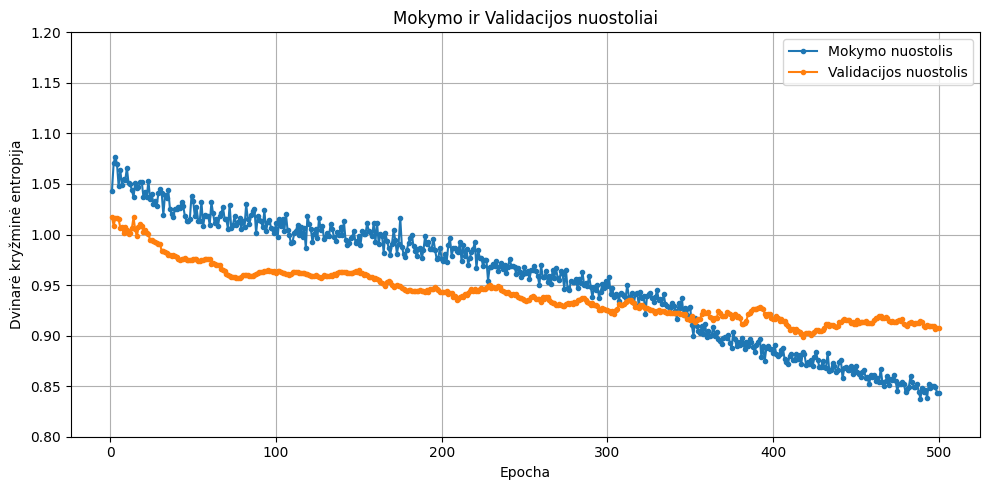

In [106]:
# plot_loss(list(trainer.train_epoch_costs), list(trainer.val_costs))
plot_loss(train_loss, val_loss, y_max=1.2, y_min=0.8)
# plot_loss(train_loss, val_loss, y_max=1.4, y_min=0.9)

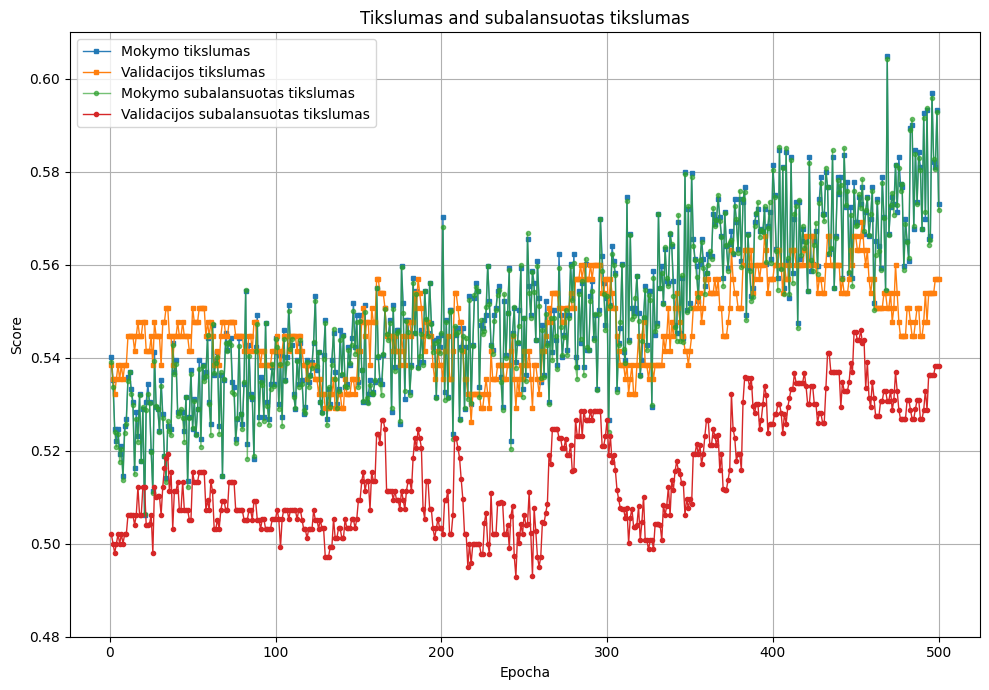

In [104]:
# plot_accuracy_metrics(trainer.train_eval_results, trainer.val_eval_results)
plot_accuracy_metrics(train_eval_results, val_eval_results, y_size=7, y_max=0.61, y_min=0.48)

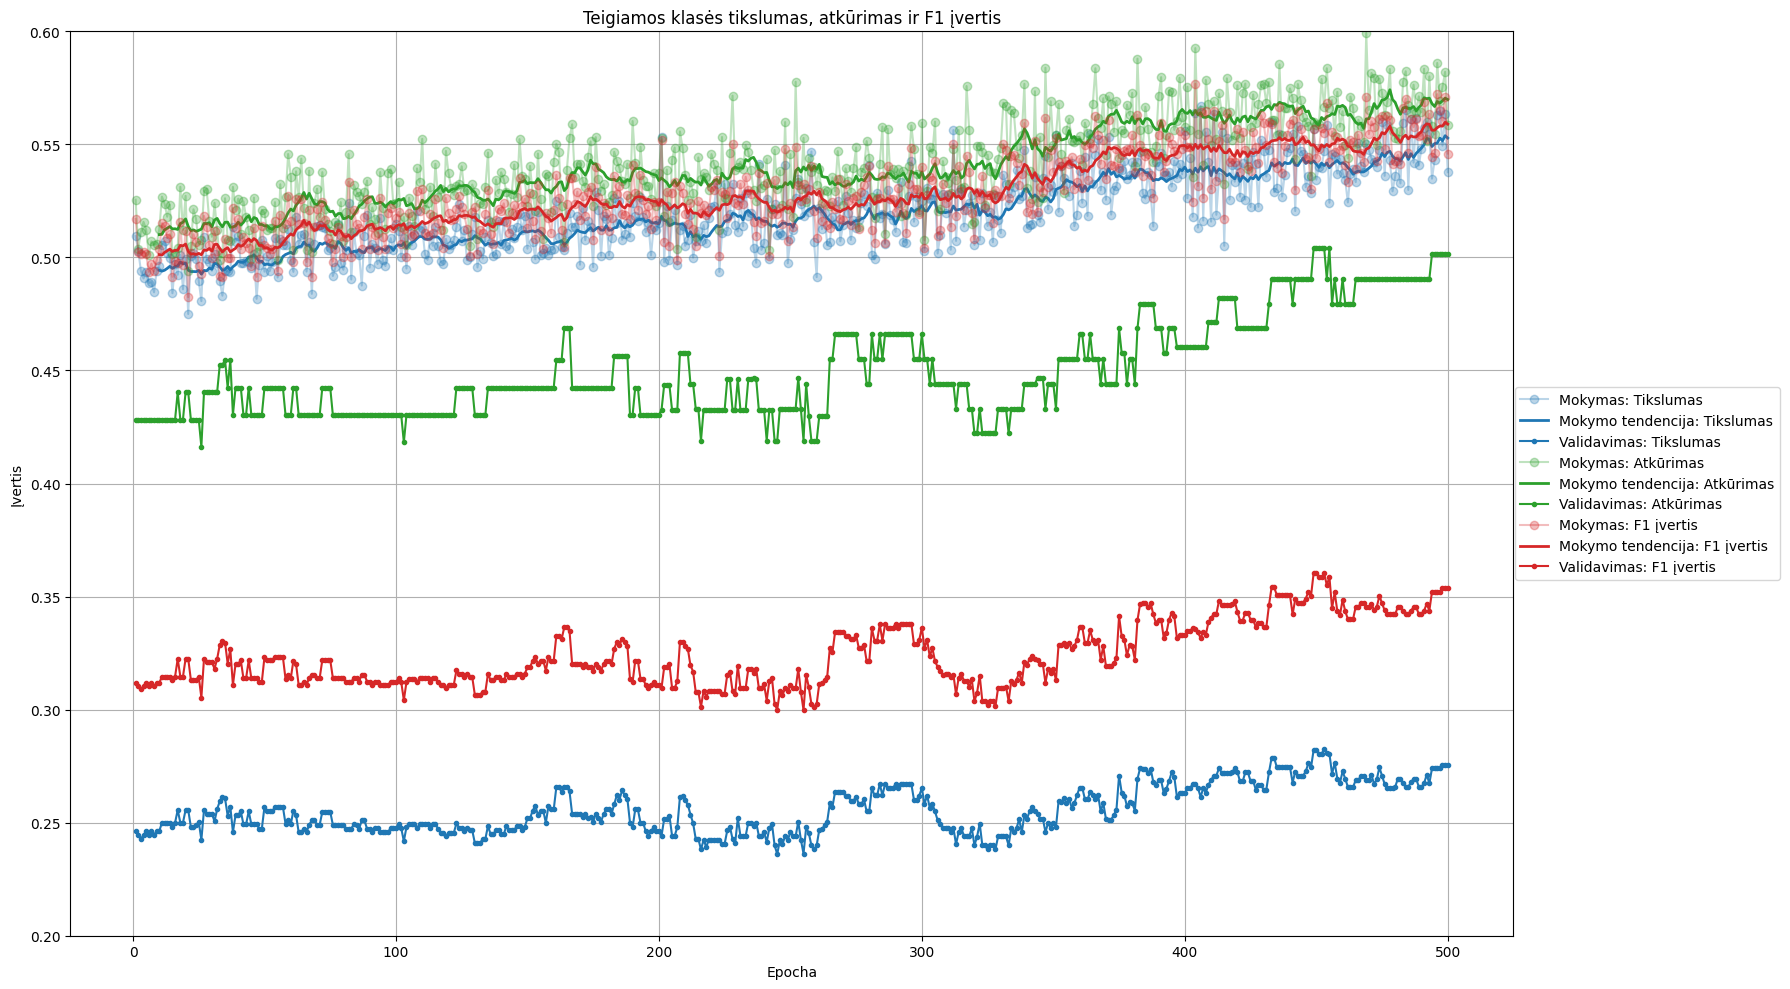

In [97]:
# plot_positive_class_metrics(train_eval_results, val_eval_results, x_size=15, y_size=8, y_max=0.6, y_min=0.2)
plot_positive_class_metrics(train_eval_results, val_eval_results, x_size=18, y_size=10, y_max=0.6, y_min=0.2, smooth_window=10)

In [ ]:
# plot_zero_vector_rate(trainer.train_eval_results, trainer.val_eval_results)
plot_zero_vector_rate(train_eval_results, val_eval_results, y_size=7, y_max=0.55, y_min=0.45)

In [ ]:
summary = {
    "train_loss": train_loss,
    "val_loss": val_loss,
    "train_metrics": train_eval_results,
    "val_metrics": val_eval_results,
}

with open(f"trained_model_summary/{log_folder}.json", "w") as f:
    json.dump(summary, f, indent=4)

### EVALUATION / DEBUGGING ###

In [ ]:

def load_model_from_diagrams(dataset_flat, backend_config, path: Path):
    model = TketModel.from_diagrams(
        dataset_flat["circuits"],
        backend_config=backend_config,
    )

    model.load(path)
    # new_model.initialise_weights()
    # old_model = load_model(save_path)
    # new_model = transfer_matching_weights(old_model, new_model)
    return model


In [ ]:
model_lt_path = Path("runs/Ma_vol3/best_model.lt")
backend_config = create_backend_config(shots=2048)

# loaded_model = load_model_from_diagrams(bf, backend_config, model_lt_path)

In [ ]:
results = evaluate_quantum_predictions(loaded_model, bf, batch_size=64)

##### debbuging

In [ ]:
def validate_circuits(model, ds_flat):
    preds = []
    n_errors = 0
    # try:
    #     preds = model.forward(ds_flat["circuits"], )
    # except Exception as e:
    #     print(f" | {e}")

    for i, circuit in enumerate(tqdm(ds_flat["circuits"])):
        try:
            preds.append(model.forward([circuit]))
        except Exception as e:
            print(f"{i} | {e}")
            n_errors += 1
    print("invalid circuits:", n_errors)
    return preds

def transfer_matching_weights(old_model, new_model):
    """
    Copies weights from old_model to new_model when symbols match.
    New symbols stay randomly initialized.
    """

    old_symbols = list(old_model.symbols)
    new_symbols = list(new_model.symbols)

    old_weights = np.array(old_model.weights)
    new_weights = np.array(new_model.weights)

    old_weight_by_symbol = {
        symbol: weight
        for symbol, weight in zip(old_symbols, old_weights)
    }

    copied = 0
    missing = 0

    for i, symbol in enumerate(new_symbols):
        if symbol in old_weight_by_symbol:
            new_weights[i] = old_weight_by_symbol[symbol]
            copied += 1
        else:
            missing += 1

    new_model.weights = new_weights

    print(f"Copied weights: {copied}")
    print(f"New/random weights: {missing}")

    return new_model


In [ ]:
preds_temp = validate_circuits(model, test_flat)

for pred in preds:
    print(pred)

In [ ]:
b = load_and_merge_encoded_batches(5, 1)
td, vd, tsd = split_encoded_batch_aligned(b, train_ratio=0.8, val_ratio=0.15)

tf = flatten_encoded_dataset(td["encoded_dataset"])
vf = flatten_encoded_dataset(vd["encoded_dataset"])
tsf = flatten_encoded_dataset(tsd["encoded_dataset"])
bf = flatten_encoded_dataset(b["encoded_dataset"])

label_distribution(tf, "train")
label_distribution(vf, "val")
label_distribution(tsf, "test")

In [ ]:
p = validate_circuits(new_model, bf)
print("valid circuits:", len(p))